# Artifact Rejection

## 1. Historical Context of EEG
---


*   **1929:** Hans Berger recorded the first human **electroencephalogram (EEG)**, discovering the alpha wave.
*   **1960s:** The **computerization** of EEG 

## 2. Introduction to EEG Signals
---
### What is EEG?
EEG signals are inherently **non-stationary**, meaning their statistical properties (like mean and variance) change over time. 

> **Definition:** Electroencephalography is the measurement, amplification, and registration of fluctuating electrical fields produced by the brain as a function of time.

#### The Spatio-Temporal Trade-off
EEG is characterized by its **high temporal resolution** (capturing changes in milliseconds) but lacks **spatial resolution** (difficulty pinpointing the exact cortical source of a signal).



#### EEG Artifacts
The primary challenge in EEG analysis is the presence of **artifacts**—signals not originating from the brain. Common examples include:
*   **Eyeblinks**
*   **Eye movements**
*   **Muscle movements (EMG)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

# --- Generate Signals ---
np.random.seed(42)
fs = 256  # Sampling frequency
t = np.linspace(0, 4, fs * 4)

# Stationary signal: fixed 10 Hz sine + constant noise
stationary = np.sin(2 * np.pi * 10 * t) + 0.3 * np.random.randn(len(t))

# Non-stationary signal: frequency & amplitude change over time (like real EEG)
non_stationary = (
    np.sin(2 * np.pi * 8 * t) * (1 + 0.5 * np.sin(2 * np.pi * 0.5 * t))  # alpha with amplitude modulation
    + np.where((t > 1.5) & (t < 2.5), 3 * np.sin(2 * np.pi * 2 * t), 0)  # transient artifact burst
    + 0.3 * np.random.randn(len(t))
)

def plot_signals(window_center=2.0, window_size=80):
    """Slide a window across both signals to inspect local statistics."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

    start = max(0, int(window_center * fs) - window_size // 2)
    end = min(len(t), start + window_size)
    
    for ax, sig, title in zip(axes, [stationary, non_stationary],
                               ["Stationary Signal (10 Hz + noise)",
                                "Non-Stationary Signal (modulated alpha + artifact burst)"]):
        ax.plot(t, sig, color="steelblue", alpha=0.6, linewidth=0.8)
        ax.axvspan(t[start], t[end - 1], color="orange", alpha=0.25, label="window")
        
        # Show local mean & std in the window
        local_mean = np.mean(sig[start:end])
        local_std = np.std(sig[start:end])
        ax.axhline(local_mean, color="red", linestyle="--", linewidth=1.2)
        ax.set_title(f"{title}  |  window μ={local_mean:.2f}, σ={local_std:.2f}", fontsize=11)
        ax.set_ylabel("Amplitude (μV)")
        ax.legend(loc="upper right", fontsize=9)
    
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

interact(
    plot_signals,
    window_center=FloatSlider(min=0.2, max=3.8, step=0.1, value=2.0, description="Center (s)"),
    window_size=IntSlider(min=30, max=256, step=10, value=80, description="Window size"),
)

interactive(children=(FloatSlider(value=2.0, description='Center (s)', max=3.8, min=0.2), IntSlider(value=80, …

<function __main__.plot_signals(window_center=2.0, window_size=80)>

# 3. Artifact Rejection: Regression & Filtering
---
### 1. Regression-based Methods
Traditionally, regression and linear filtering-based analyses are employed to reject artifactual noises from corrupted signals.

*   **Mechanism:** These methods rely on extra regressive channels (like an EOG channel) to "subtract" noise.
*   **Weakness:** A fundamental weakness is that the **spectral range** of some artifacts overlaps with the spectral range of the actual EEG signal, potentially leading to the loss of real neural data.

# 4. The Wavelet Transform (WT)
---
Transforming a time-domain signal into the **time-frequency domain** offers major advantages in extracting multiple components of a signal.

The wavelet transform decomposes a time-domain signal into its **wavelet coefficients** through a **mother wavelet function**. These coefficients are obtained by performing shifting and dilation of the mother wavelet:

$$ \Psi_{a,b}(t) = \Psi \left( \frac{t-b}{a} \right) $$

Where:
*   **$a$**: The scaling parameter.
*   **$b$**: The shifting parameter.

#### Types of Wavelet Transform
1.  **Discrete Wavelet Transform (DWT)**
2.  **Continuous Wavelet Transform (CWT)**
3.  **Stationary Wavelet Transform (SWT)**

The coefficients are modified by taking advantage of their local properties, and the transformation is then inverted to obtain a clean version of the signal.

> **Intuition - The Choice of Wavelet:** 
> Choice of wavelet matters. Imagine zooming in and out of a signal with differently stretched oscillatory lenses. You want to pick a "lens" (mother wavelet) that most closely mirrors the shape of the feature (e.g., a blink or a spike) you are trying to isolate.

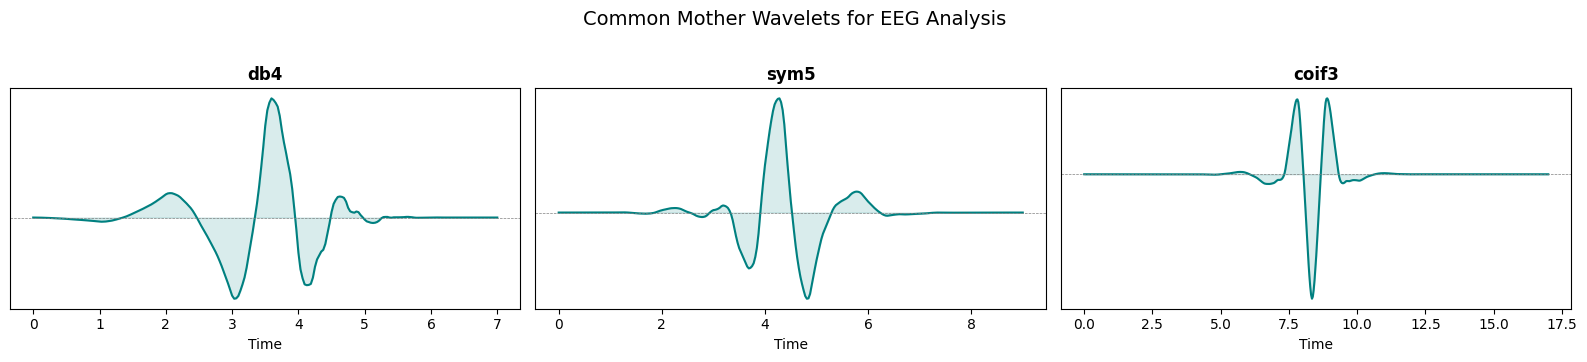

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# --- Visualise common mother wavelets used in EEG ---
wavelet_names = ["db4", "sym5", "coif3"]
fig, axes = plt.subplots(1, len(wavelet_names), figsize=(16, 3.5))

for ax, name in zip(axes, wavelet_names):
    try:
        wav = pywt.ContinuousWavelet(name)
        # For continuous wavelets use pywt's wavefun
        [psi, x] = wav.wavefun(precision=10)
    except Exception:
        wav = pywt.Wavelet(name)
        [phi, psi, x] = wav.wavefun(level=5)[:3]
    
    ax.plot(x, psi, color="teal", linewidth=1.5)
    ax.fill_between(x, psi, alpha=0.15, color="teal")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Time")
    ax.set_yticks([])

fig.suptitle("Common Mother Wavelets for EEG Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

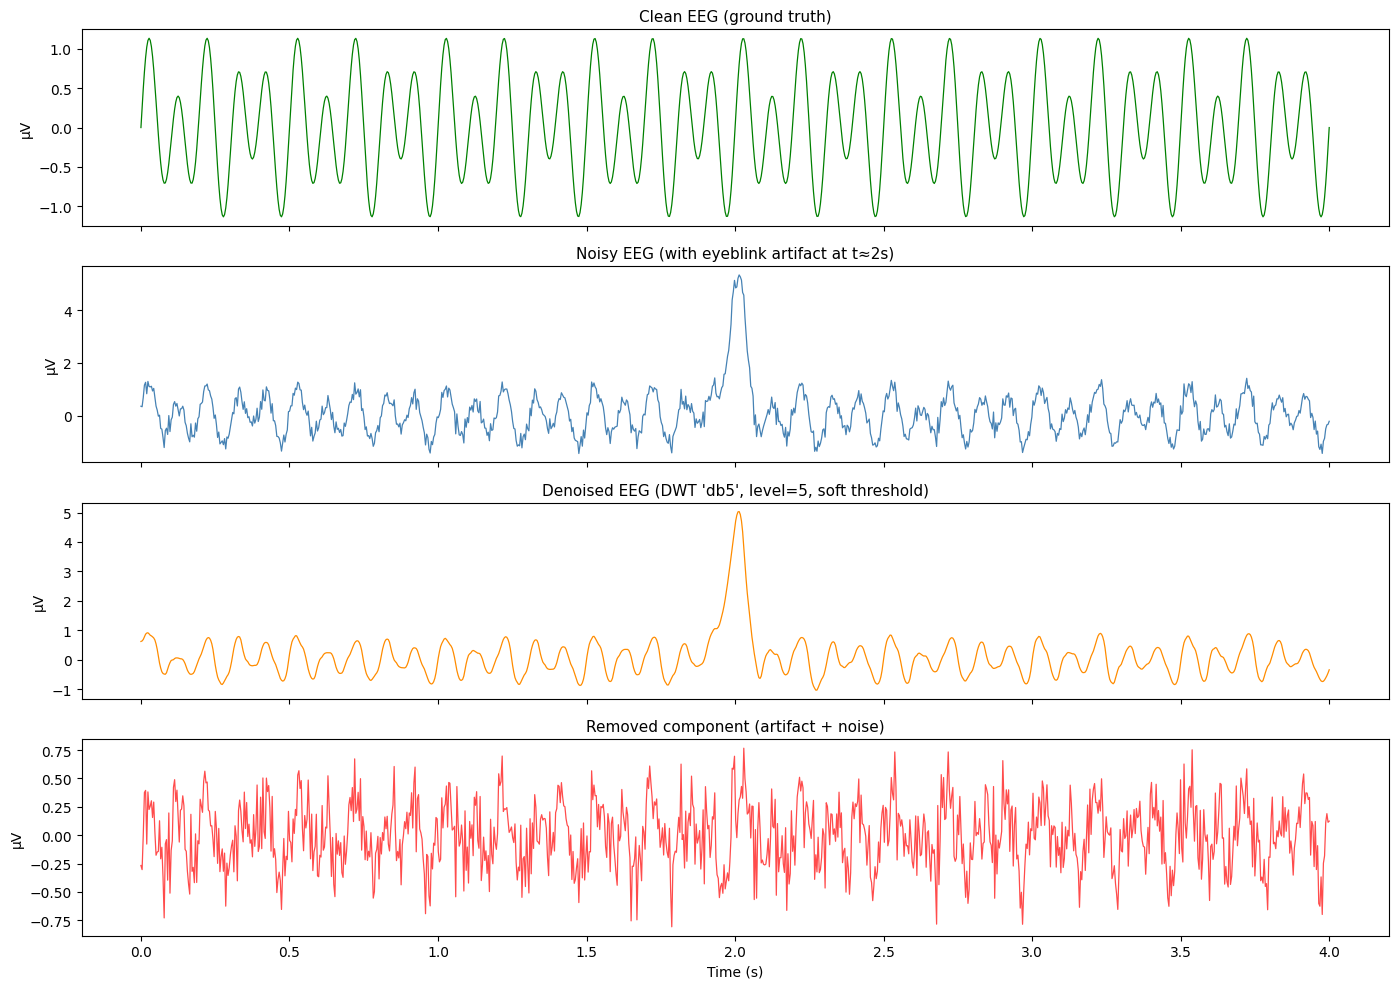

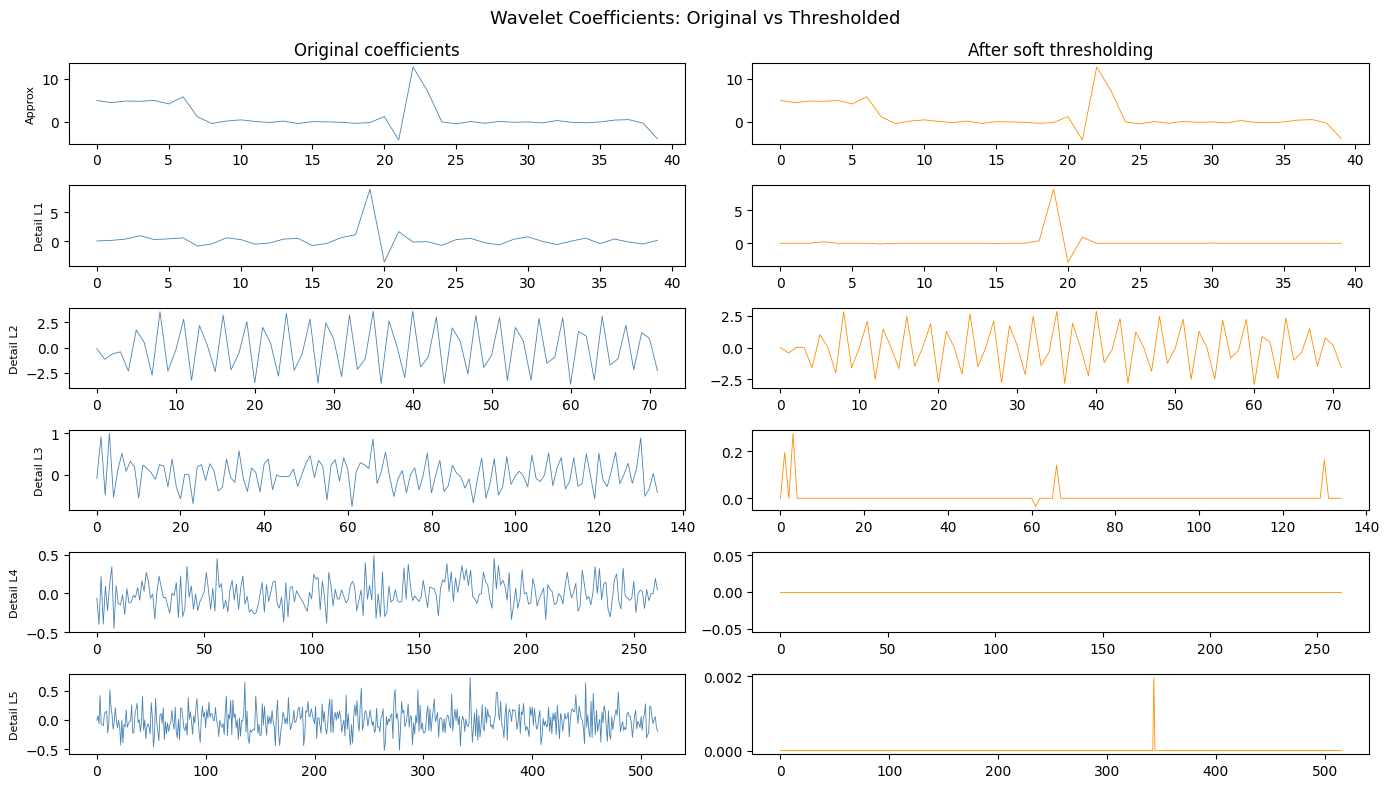

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# --- Create a synthetic EEG-like signal with an eyeblink artifact ---
np.random.seed(0)
fs = 256
t = np.linspace(0, 4, fs * 4)

# Clean EEG: alpha (10 Hz) + beta (20 Hz)
clean_eeg = 0.8 * np.sin(2 * np.pi * 10 * t) + 0.4 * np.sin(2 * np.pi * 6* t)

# Eyeblink artifact: a broad Gaussian bump around t=2s
blink = 5 * np.exp(-((t - 2.0) ** 2) / (2 * 0.03**2))

# Noisy signal
noisy_eeg = clean_eeg + blink + 0.2 * np.random.randn(len(t))

# --- DWT Denoising with soft thresholding ---
wavelet = "db5"
level = 5
coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)

# Estimate noise std from the finest detail coefficients (MAD estimator)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(noisy_eeg)))  # Universal threshold

# Apply soft thresholding to detail coefficients (keep approximation)
coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode="soft") for c in coeffs[1:]]
denoised_eeg = pywt.waverec(coeffs_thresh, wavelet)[:len(t)]

# --- Plot results ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t, clean_eeg, color="green", linewidth=0.9)
axes[0].set_title("Clean EEG (ground truth)", fontsize=11)

axes[1].plot(t, noisy_eeg, color="steelblue", linewidth=0.9)
axes[1].set_title("Noisy EEG (with eyeblink artifact at t≈2s)", fontsize=11)

axes[2].plot(t, denoised_eeg, color="darkorange", linewidth=0.9)
axes[2].set_title(f"Denoised EEG (DWT '{wavelet}', level={level}, soft threshold)", fontsize=11)

axes[3].plot(t, noisy_eeg - denoised_eeg, color="red", linewidth=0.9, alpha=0.7)
axes[3].set_title("Removed component (artifact + noise)", fontsize=11)
axes[3].set_xlabel("Time (s)")

for ax in axes:
    ax.set_ylabel("μV")
plt.tight_layout()
plt.show()

# --- Show wavelet coefficients before & after thresholding ---
fig2, axes2 = plt.subplots(level + 1, 2, figsize=(14, 8))
fig2.suptitle("Wavelet Coefficients: Original vs Thresholded", fontsize=13)

labels = ["Approx"] + [f"Detail L{i}" for i in range(1, level + 1)]
for i, (orig, thresh, label) in enumerate(zip(coeffs, coeffs_thresh, labels)):
    axes2[i, 0].plot(orig, color="steelblue", linewidth=0.6)
    axes2[i, 0].set_ylabel(label, fontsize=8)
    axes2[i, 1].plot(thresh, color="darkorange", linewidth=0.6)
    if i == 0:
        axes2[i, 0].set_title("Original coefficients")
        axes2[i, 1].set_title("After soft thresholding")

plt.tight_layout()
plt.show()

# 5. Empirical Mode Decomposition (EMD)
---
Unlike Wavelet Transforms which use predefined basis functions, **EMD** is a data-driven approach. It discovers oscillatory modes directly from the signal itself.

### What are IMFs?
EMD decomposes a signal into **Intrinsic Mode Functions (IMFs)**.

Mode: Refers to a portion of the signal that represents a specific oscillation or trend.

Decomposition: The process of separating a signal into simpler, physically meaningful components.

 IMFs are the components extracted from the signal during EMD. Each IMF represents a simple oscillatory mode embedded in the data.

Each IMF is:
*   **Locally symmetric**
*   **Narrow-band-ish**
*   **Oscillatory**

The signal is represented as:
$$\text{Signal} = \sum_{i=1}^{n} \text{IMF}_i + \text{residual}$$


IMFs: Ordered from highest to lowest frequency (smallest to largest scales).

Residual: Represents the trend or mean of the signal after all IMFs are extracted.

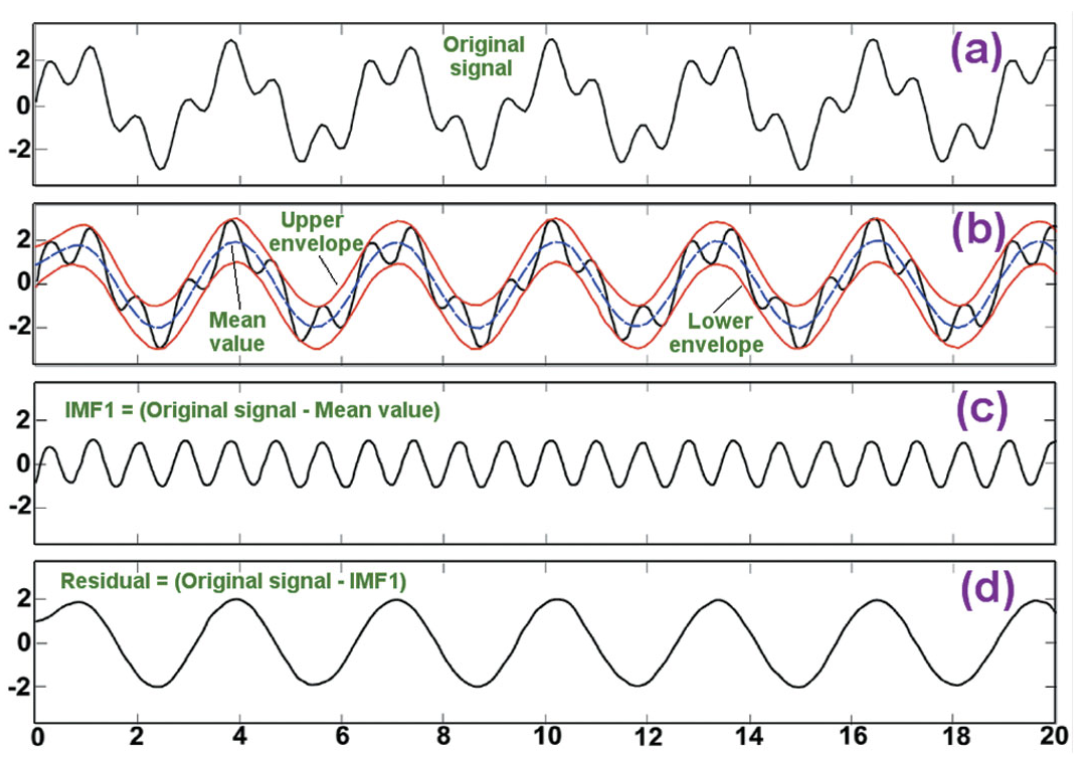

### Why use EMD for EEG?
*   **No Assumptions:** It does not assume sinusoids (like Fourier) or wavelets.
*   **Biological Fit:** Modes emerge from the signal, making it ideal for **neural oscillations** which are often messy, non-linear, and non-stationary.

### The Major Issue: Mode Mixing
A common problem in EMD is **Mode Mixing**, where:
1.  A single IMF contains multiple disparate frequencies.
2.  A single frequency component is split across multiple IMFs.
*This is especially prevalent in noisy data.*

IMF      SampEn      |r|       E%     Kurt    DomHz │ Entro  Corre  Energ  Kurto  Frequ  Combi
───────────────────────────────────────────────────────────────────────────────────────────────
IMF 1    1.5041   0.1131    1.07%    -0.94    98.00 │     ·    ██     ·     ·     ·     · 
IMF 2    0.9260   0.2262    3.86%    -0.58    22.00 │     ·     ·     ·     ·     ·     · 
IMF 3    0.5384   0.3623   16.10%    -0.83    10.00 │     ·     ·     ·     ·     ·     · 
IMF 4    0.4247   0.2338    5.39%     2.89     5.00 │     ·     ·     ·     ·     ·     · 
IMF 5    0.3016   0.1191    3.36%     3.60     2.00 │    ██    ██     ·     ·     ·    ██ 
IMF 6    0.0325   0.7806   61.28%    -1.32     1.00 │    ██     ·    ██     ·    ██    ██ 
IMF 7    0.0123   0.1359    8.93%    -0.58     1.00 │    ██    ██     ·     ·    ██    ██ 


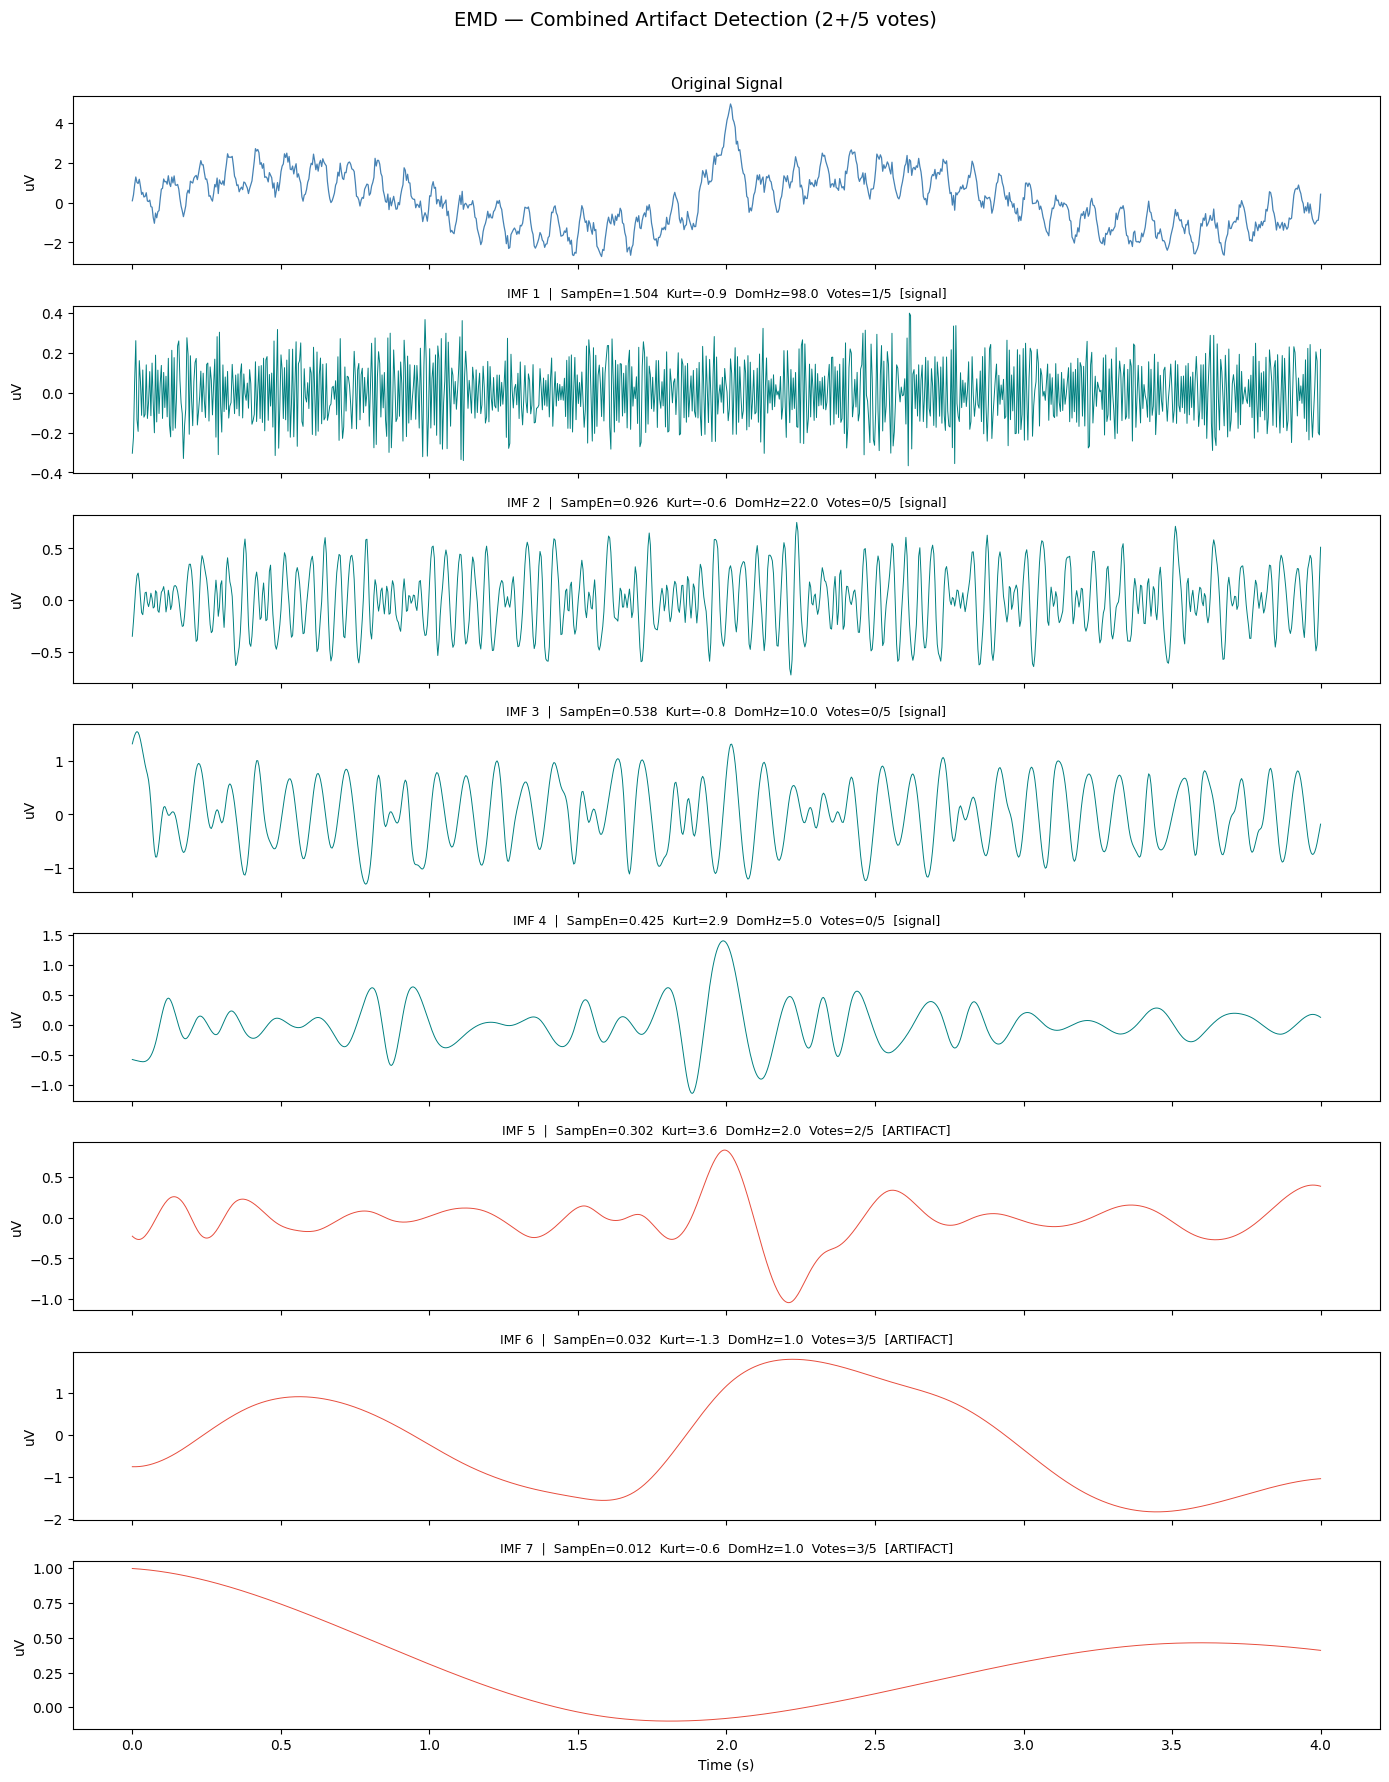


Method          Removed IMFs             RMSE        R
───────────────────────────────────────────────────────
Entropy         IMF 5,6,7              0.3505   0.8746
Correlation     IMF 1,5,7              1.1828   0.4758
Energy          IMF 6                  0.6355   0.7477
Kurtosis        IMF                    1.1897   0.4714
Frequency       IMF 6,7                0.4710   0.8003
Combined        IMF 5,6,7              0.3505   0.8746


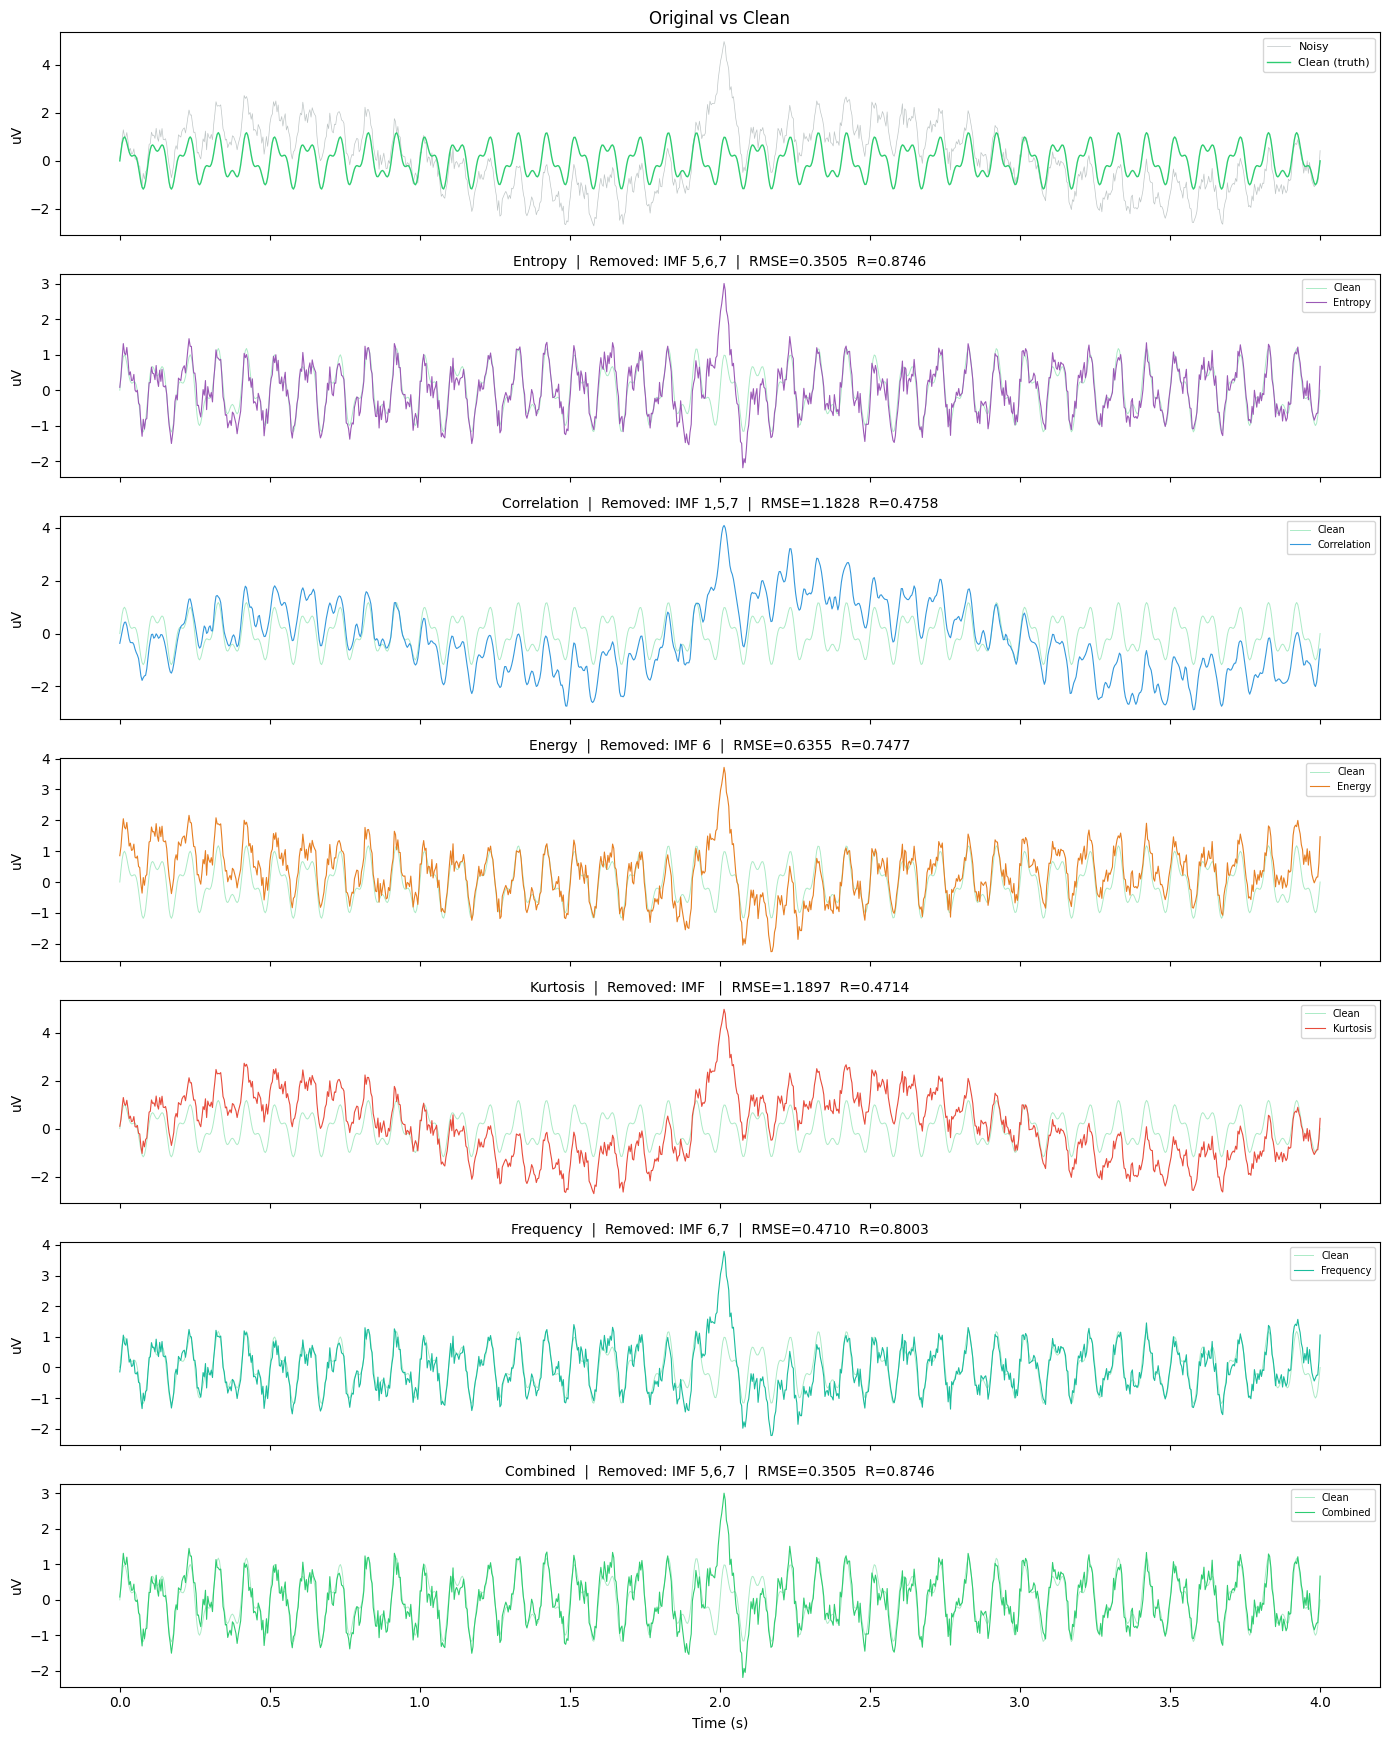

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
from scipy.stats import pearsonr, kurtosis
from scipy.signal import welch

# --- Create a synthetic EEG-like signal ---
np.random.seed(42)
fs = 256
t = np.linspace(0, 4, fs * 4)

# Clean EEG (ground truth for evaluation)
clean_eeg = 0.8 * np.sin(2 * np.pi * 10 * t) + 0.4 * np.sin(2 * np.pi * 22 * t)

# Artifacts
blink = 4 * np.exp(-((t - 2.0) ** 2) / (2 * 0.04**2))
drift = 1.5 * np.sin(2 * np.pi * 0.5 * t)
noise = 0.2 * np.random.randn(len(t))

signal = clean_eeg + blink + drift + noise

# --- Run EMD ---
emd = EMD()
imfs = emd.emd(signal, t)
n_imfs = imfs.shape[0]


# ═══════════════════════════════════════════════════════════════════════
# IMF REJECTION METHODS
# ═══════════════════════════════════════════════════════════════════════

# --- 1. Sample Entropy (low = regular/artifact) ---
def sample_entropy(x, m=2, r_frac=0.2):
    x = np.asarray(x, dtype=float)
    N = len(x)
    r = r_frac * np.std(x)
    if r == 0 or N < m + 2:
        return 0.0
    def _count(tl):
        templates = np.lib.stride_tricks.sliding_window_view(x, tl)
        count = 0
        for i in range(len(templates)):
            dists = np.max(np.abs(templates[i] - templates), axis=1)
            count += np.sum(dists < r) - 1
        return count
    A, B = _count(m + 1), _count(m)
    if B == 0 or A == 0:
        return 0.0
    return -np.log(A / B)

def largest_gap_mask(values, low_is_artifact=True):
    """Flag components below (or above) the largest gap in sorted values."""
    n = len(values)
    if n <= 1:
        return np.zeros(n, dtype=bool)
    sorted_idx = np.argsort(values) if low_is_artifact else np.argsort(-values)
    sorted_vals = values[sorted_idx]
    diffs = np.diff(sorted_vals)
    k = max(1, min(np.argmax(diffs) + 1, n // 2))
    mask = np.zeros(n, dtype=bool)
    mask[sorted_idx[:k]] = True
    return mask

entropies = np.array([sample_entropy(imf[:200]) for imf in imfs])
mask_entropy = largest_gap_mask(entropies, low_is_artifact=True)


# --- 2. Correlation with original signal (low |r| = artifact) ---
correlations = np.array([abs(pearsonr(imf, signal)[0]) for imf in imfs])
mask_corr = largest_gap_mask(correlations, low_is_artifact=True)


# --- 3. Energy ratio (unusually high energy = blink artifact) ---
energies = np.array([np.sum(imf**2) for imf in imfs])
energy_ratio = energies / energies.sum()
energy_thresh = np.mean(energy_ratio) + 2 * np.std(energy_ratio)
mask_energy = energy_ratio > energy_thresh


# --- 4. Kurtosis (high kurtosis = sharp transients like blinks) ---
kurt = np.array([kurtosis(imf) for imf in imfs])
mask_kurt = kurt > 5


# --- 5. Dominant frequency (< 2 Hz = drift artifact) ---
dom_freqs = []
for imf in imfs:
    f, psd = welch(imf, fs=fs, nperseg=min(256, len(imf)))
    dom_freqs.append(f[np.argmax(psd)])
dom_freqs = np.array(dom_freqs)
mask_freq = dom_freqs < 2.0


# --- 6. Combined vote (artifact if 2+ methods agree) ---
votes = (mask_entropy.astype(int) + mask_corr.astype(int) +
         mask_energy.astype(int) + mask_kurt.astype(int) +
         mask_freq.astype(int))
mask_combined = votes >= 2


# ═══════════════════════════════════════════════════════════════════════
# PRINT DIAGNOSTICS TABLE
# ═══════════════════════════════════════════════════════════════════════

all_methods = {
    'Entropy':     mask_entropy,
    'Correlation': mask_corr,
    'Energy':      mask_energy,
    'Kurtosis':    mask_kurt,
    'Frequency':   mask_freq,
    'Combined':    mask_combined,
}

print(f"{'IMF':<6} {'SampEn':>8} {'|r|':>8} {'E%':>8} {'Kurt':>8} {'DomHz':>8} │ ", end="")
print("  ".join(f"{m[:5]:>5}" for m in all_methods))
print("─" * 95)
for i in range(n_imfs):
    print(f"IMF {i+1:<2} {entropies[i]:8.4f} {correlations[i]:8.4f} "
          f"{energy_ratio[i]*100:7.2f}% {kurt[i]:8.2f} {dom_freqs[i]:8.2f} │ ", end="")
    for name, mask in all_methods.items():
        tag = "  ██" if mask[i] else "   ·"
        print(f" {tag} ", end="")
    print()


# ═══════════════════════════════════════════════════════════════════════
# PLOT: IMFs coloured by combined artifact mask
# ═══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 2.2 * (n_imfs + 1)), sharex=True)
axes[0].plot(t, signal, color="steelblue", linewidth=0.9)
axes[0].set_title("Original Signal", fontsize=11)
axes[0].set_ylabel("uV")

for i in range(n_imfs):
    is_art = mask_combined[i]
    color = "#e74c3c" if is_art else "teal"
    label = "ARTIFACT" if is_art else "signal"
    axes[i+1].plot(t, imfs[i], color=color, linewidth=0.7)
    axes[i+1].set_title(
        f"IMF {i+1}  |  SampEn={entropies[i]:.3f}  Kurt={kurt[i]:.1f}  "
        f"DomHz={dom_freqs[i]:.1f}  Votes={votes[i]}/5  [{label}]", fontsize=9)
    axes[i+1].set_ylabel("uV")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EMD — Combined Artifact Detection (2+/5 votes)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# COMPARE ALL METHODS: reconstruction vs clean ground truth
# ═══════════════════════════════════════════════════════════════════════

method_colors = {
    'Entropy': '#9b59b6', 'Correlation': '#3498db', 'Energy': '#e67e22',
    'Kurtosis': '#e74c3c', 'Frequency': '#1abc9c', 'Combined': '#2ecc71',
}

fig, axes = plt.subplots(len(all_methods) + 1, 1,
                          figsize=(14, 2.5 * (len(all_methods) + 1)), sharex=True)

axes[0].plot(t, signal, color='#7f8c8d', lw=0.5, alpha=0.5, label='Noisy')
axes[0].plot(t, clean_eeg, color='#2ecc71', lw=1, label='Clean (truth)')
axes[0].set_title('Original vs Clean'); axes[0].legend(fontsize=8); axes[0].set_ylabel('uV')

print(f"\n{'Method':<15} {'Removed IMFs':<20} {'RMSE':>8} {'R':>8}")
print("─" * 55)

for idx, (name, mask) in enumerate(all_methods.items()):
    recon = np.sum(imfs[~mask], axis=0)
    rmse = np.sqrt(np.mean((clean_eeg - recon)**2))
    r, _ = pearsonr(clean_eeg, recon)
    removed = [str(i+1) for i in range(n_imfs) if mask[i]]

    ax = axes[idx + 1]
    ax.plot(t, clean_eeg, color='#2ecc71', lw=0.7, alpha=0.4, label='Clean')
    ax.plot(t, recon, color=method_colors[name], lw=0.8, label=name)
    ax.set_title(f'{name}  |  Removed: IMF {",".join(removed)}  |  RMSE={rmse:.4f}  R={r:.4f}',
                 fontsize=10)
    ax.set_ylabel('uV'); ax.legend(fontsize=7, loc='upper right')

    print(f"{name:<15} IMF {','.join(removed):<16} {rmse:8.4f} {r:8.4f}")

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


# 6. Improving EMD: EEMD & CEEMDAN
---
To solve the "Mode Mixing" problem, we use ensemble-based approaches that leverage noise to stabilize the decomposition.

### A. Ensemble EMD (EEMD)
Counterintuitively, **adding noise improves robustness**. 
*   **How it works:** We add random white noise to the signal many times. For each noisy realization, we run EMD and then average the corresponding IMFs.
*   **Intuition:** Noise fills the time-frequency space uniformly, which helps "guide" the decomposition and prevents frequencies from hopping between modes.

**The Workflow:**
1. $x(t) + w_i(t)$ (Add noise)
2. Run EMD repeatedly to get $IMF_i^{(k)}$
3. $\bar{IMF}_i$ (Average results)

### B. CEEMDAN
**Complete Ensemble EMD with Adaptive Noise (CEEMDAN)** is a further refinement. It uses complementary positive and negative noise pairs to reduce reconstruction error and computational cost, providing a more complete and stable decomposition.


  EMD  (8 IMFs)
IMF      SampEn      |r|       E%     Kurt    DomHz | Entro  Corre  Energ  Kurto  Frequ  Combi
--------------------------------------------------------------------------------
IMF 1    1.2635   0.0161   47.35%     1.96    60.00 |     .    ##     .     .     .     . 
IMF 2    0.7707   0.0375    9.72%    -0.92    30.00 |     .    ##     .     .     .     . 
IMF 3    0.6099   0.3899   39.75%    -1.31    10.00 |     .     .     .     .     .     . 
IMF 4    0.4443   0.0456    2.36%     2.85     5.00 |     .    ##     .     .     .     . 
IMF 5    0.2361   0.0059    0.67%     0.66     3.00 |    ##    ##     .     .     .    ## 
IMF 6    0.0517   0.1113    0.11%    -0.72     1.00 |    ##     .     .     .    ##    ## 
IMF 7    0.0461   0.3578    0.01%    -1.21     1.00 |    ##     .     .     .    ##    ## 
IMF 8    0.0122   0.2181    0.02%    -1.13     1.00 |    ##     .     .     .    ##    ## 

  EEMD  (9 IMFs)
IMF      SampEn      |r|       E%     Kurt    DomHz | Entro  

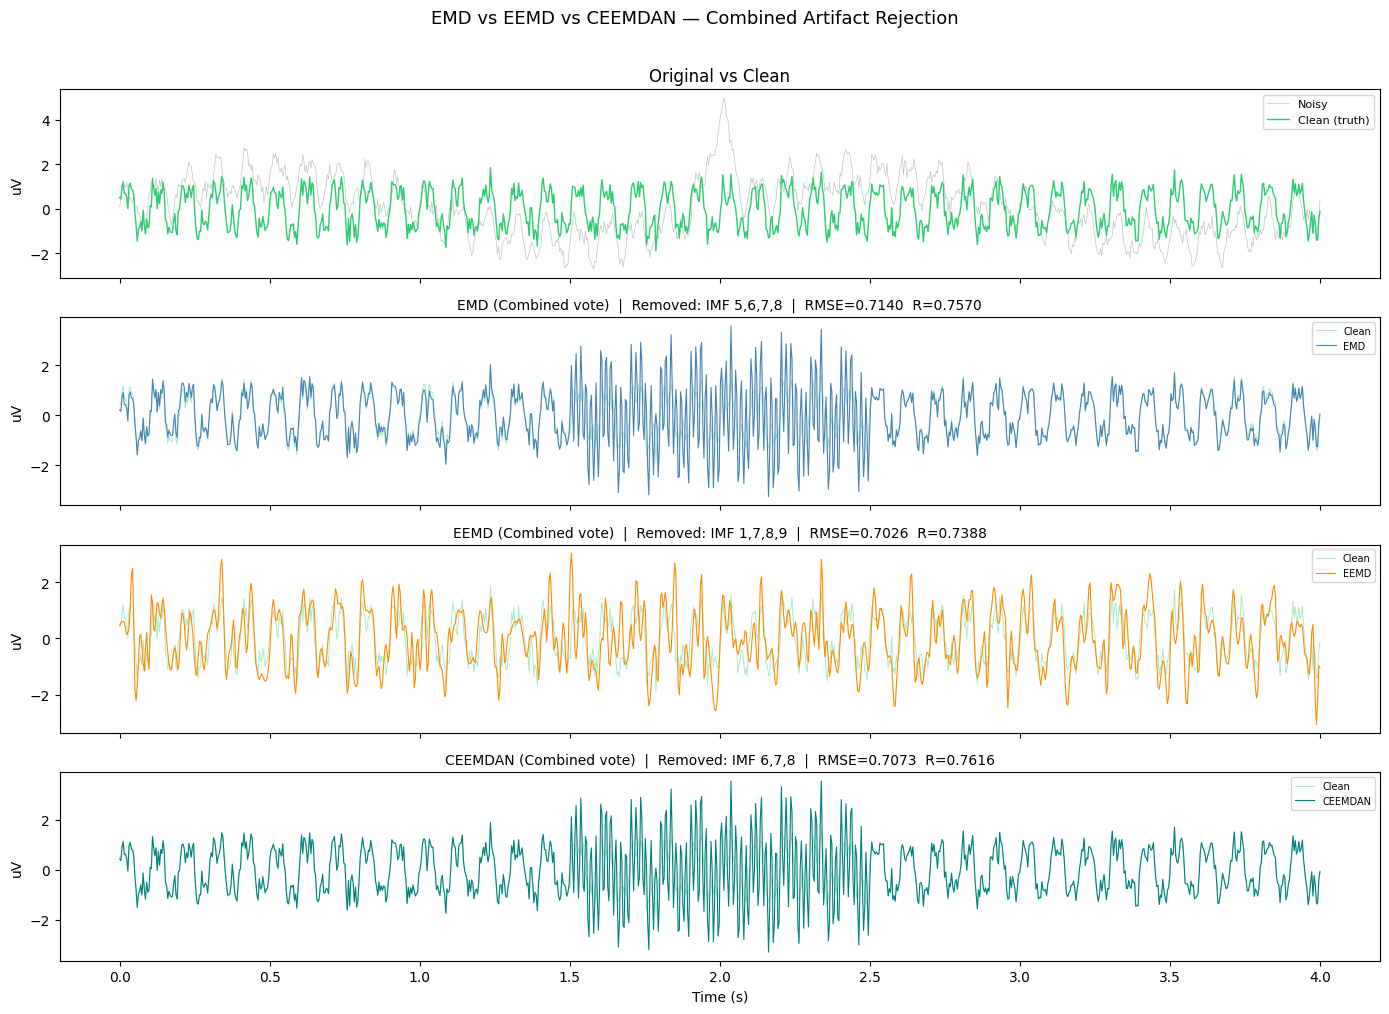

In [25]:
from scipy.stats import pearsonr, kurtosis


# Clean signal (ground truth — signal without the burst artifact)
# Realistic clean EEG: multiple rhythms with amplitude modulation
# Clean = signal without the intermittent burst artifact
clean = (np.sin(2 * np.pi * 10 * t)
         + 0.5 * np.sin(2 * np.pi * 30 * t)
         + 0.3 * np.random.RandomState(7).randn(len(t)))

def compute_all_masks(imfs, signal, fs):
    """Compute all 5 rejection masks + combined for a set of IMFs."""
    n = imfs.shape[0]

    # 1. Entropy
    ent = np.array([sample_entropy(imf[:200]) for imf in imfs])
    m_ent = largest_gap_mask(ent, low_is_artifact=True)

    # 2. Correlation
    corr = np.array([abs(pearsonr(imf, signal)[0]) for imf in imfs])
    m_corr = largest_gap_mask(corr, low_is_artifact=True)

    # 3. Energy
    energy = np.array([np.sum(imf**2) for imf in imfs])
    eratio = energy / energy.sum()
    m_energy = eratio > np.mean(eratio) + 2 * np.std(eratio)

    # 4. Kurtosis
    kurt = np.array([kurtosis(imf) for imf in imfs])
    m_kurt = kurt > 5

    # 5. Dominant frequency
    domf = []
    for imf in imfs:
        f, psd = welch(imf, fs=fs, nperseg=min(256, len(imf)))
        domf.append(f[np.argmax(psd)])
    domf = np.array(domf)
    m_freq = domf < 2.0

    # 6. Combined (2+ votes)
    votes = (m_ent.astype(int) + m_corr.astype(int) + m_energy.astype(int)
             + m_kurt.astype(int) + m_freq.astype(int))
    m_combined = votes >= 2

    return {
        'Entropy': m_ent, 'Correlation': m_corr, 'Energy': m_energy,
        'Kurtosis': m_kurt, 'Frequency': m_freq, 'Combined': m_combined,
    }, {'ent': ent, 'corr': corr, 'eratio': eratio, 'kurt': kurt, 'domf': domf, 'votes': votes}


# --- Run rejection on all three decompositions ---
decompositions = [
    ('EMD',     imfs_emd),
    ('EEMD',    imfs_eemd),
    ('CEEMDAN', imfs_ceemdan),
]

all_results = {}
for dec_name, imfs in decompositions:
    masks, metrics = compute_all_masks(imfs,signal , fs)
    all_results[dec_name] = {'imfs': imfs, 'masks': masks, 'metrics': metrics}

    # Print diagnostics
    n_imfs = imfs.shape[0]
    print(f"\n{'='*80}")
    print(f"  {dec_name}  ({n_imfs} IMFs)")
    print(f"{'='*80}")
    print(f"{'IMF':<6} {'SampEn':>8} {'|r|':>8} {'E%':>8} {'Kurt':>8} {'DomHz':>8} | ", end="")
    print("  ".join(f"{m[:5]:>5}" for m in masks))
    print("-" * 80)
    for i in range(n_imfs):
        print(f"IMF {i+1:<2} {metrics['ent'][i]:8.4f} {metrics['corr'][i]:8.4f} "
              f"{metrics['eratio'][i]*100:7.2f}% {metrics['kurt'][i]:8.2f} "
              f"{metrics['domf'][i]:8.2f} | ", end="")
        for name, mask in masks.items():
            tag = "  ##" if mask[i] else "   ."
            print(f" {tag} ", end="")
        print()


    # --- Grand comparison: RMSE & R for every decomposition x rejection method ---
print(f"\n{'='*70}")
print(f"{'Decomposition':<12} {'Rejection':<15} {'Removed':<18} {'RMSE':>8} {'R':>8}")
print(f"{'='*70}")

summary_results = {}
for dec_name, data in all_results.items():
    imfs = data['imfs']
    for rej_name, mask in data['masks'].items():
        recon = np.sum(imfs[~mask], axis=0)
        n = min(len(clean), len(recon))
        rmse = np.sqrt(np.mean((clean[:n] - recon[:n])**2))
        r, _ = pearsonr(clean[:n], recon[:n])
        removed = ",".join(str(i+1) for i in range(len(mask)) if mask[i])
        if not removed:
            removed = "none"
        summary_results[(dec_name, rej_name)] = {'recon': recon, 'rmse': rmse, 'r': r}
        print(f"{dec_name:<12} {rej_name:<15} IMF {removed:<14} {rmse:8.4f} {r:8.4f}")
    print(f"{'-'*70}")


# --- Plot: Combined rejection for each decomposition ---
dec_colors = {'EMD': 'steelblue', 'EEMD': 'darkorange', 'CEEMDAN': 'teal'}

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t, signal, color='#7f8c8d', lw=0.5, alpha=0.5, label='Noisy')
axes[0].plot(t, clean, color='#2ecc71', lw=1, label='Clean (truth)')
axes[0].set_title('Original vs Clean'); axes[0].legend(fontsize=8); axes[0].set_ylabel('uV')

for idx, (dec_name, data) in enumerate(all_results.items()):
    mask = data['masks']['Combined']
    imfs = data['imfs']
    recon = np.sum(imfs[~mask], axis=0)
    n = min(len(clean), len(recon))
    rmse = np.sqrt(np.mean((clean[:n] - recon[:n])**2))
    r, _ = pearsonr(clean[:n], recon[:n])
    removed = ",".join(str(i+1) for i in range(len(mask)) if mask[i]) or "none"

    ax = axes[idx + 1]
    ax.plot(t, clean, color='#2ecc71', lw=0.7, alpha=0.4, label='Clean')
    ax.plot(t[:len(recon)], recon, color=dec_colors[dec_name], lw=0.8, label=dec_name)
    ax.set_title(f'{dec_name} (Combined vote)  |  Removed: IMF {removed}  |  '
                 f'RMSE={rmse:.4f}  R={r:.4f}', fontsize=10)
    ax.set_ylabel('uV'); ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EMD vs EEMD vs CEEMDAN — Combined Artifact Rejection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 7. Evaluation and Choice of Parameters
These methods (WT, EMD, ICA) are often paired and then evaluated using **Entropy Thresholds** to determine which components are noise and which are signal.

---
**Bottom Line:** Whether using Wavelets or the EMD family (EEMD, CEEMDAN), these techniques can all be cross-paired with ICA to create a robust, multi-stage cleaning pipeline for EEG.